# Artifact Exploration — single-run deep-dive

Deep-dive into what one training run produced under `artifacts/<model>_<timestamp>/`.
**Set `MODEL` in the first code cell** to `lightgbm` / `xgboost` / `catboost` / `gru`; the
notebook loads that family's **latest** run. Tree-only sections (feature importance) skip
automatically for the GRU.

This notebook reads **only the saved artifacts** (no retraining), so it's fast and reproducible:

- `metrics.json` — overall + breakdowns + business proxy for **train / val / test**
- `run_meta.json` — seed, package versions, timings, row counts, best_iteration
- `feature_importance.csv` — ranked importances
- `breakdown_{channel,category,promo,stockout}_test.csv`
- `predictions_{test,val}.parquet` — per-row predictions + context for failure-mode analysis

It covers: overall accuracy, overfit check, stockout censoring effect, segment breakdowns, business cost, feature importance, and failure modes (sparse SKUs, promo spikes, drift).

In [1]:
from pathlib import Path
import json

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

pd.set_option("display.float_format", lambda v: f"{v:,.4f}")

PROJECT_ROOT = Path.cwd()
if PROJECT_ROOT.name == "notebooks":
    PROJECT_ROOT = PROJECT_ROOT.parent
ARTIFACTS = PROJECT_ROOT / "artifacts"

# Deep-dive on ONE run. Set MODEL to any trained family; we load its LATEST run.
#   trees -> "lightgbm" | "xgboost" | "catboost"  (feature importance available)
#   dl    -> "gru"                                  (feature-importance cell auto-skips)
MODEL = "lightgbm"

runs = [d for d in ARTIFACTS.glob(f"{MODEL}_*/") if d.is_dir()]
assert runs, f"No '{MODEL}' run found in artifacts/ — train it first."
RUN_DIR = max(runs, key=lambda p: p.stat().st_mtime)
print(f"Exploring {MODEL} run:", RUN_DIR.name)

Exploring lightgbm run: lightgbm_20260903_185246


In [2]:
def load_run(run_dir: Path) -> dict:
    art = {}
    with open(run_dir / "metrics.json") as f:
        art["metrics"] = json.load(f)
    with open(run_dir / "run_meta.json") as f:
        art["run_meta"] = json.load(f)
    fi = run_dir / "feature_importance.csv"
    art["feature_importance"] = pd.read_csv(fi) if fi.exists() else None
    for name in ["channel", "category", "promo", "stockout"]:
        fp = run_dir / f"breakdown_{name}_test.csv"
        art[f"breakdown_{name}"] = pd.read_csv(fp) if fp.exists() else None
    art["pred_test"] = pd.read_parquet(run_dir / "predictions_test.parquet")
    fp_val = run_dir / "predictions_val.parquet"
    art["pred_val"] = pd.read_parquet(fp_val) if fp_val.exists() else None
    return art

art = load_run(RUN_DIR)
metrics, run_meta = art["metrics"], art["run_meta"]
pred_test = art["pred_test"]

# Model-agnostic header: show whatever scalar model-info keys the run has.
print(f"model           : {metrics['model']}")
for k, v in metrics.items():
    if k not in ('model', 'params', 'train', 'val', 'test') and not isinstance(v, (dict, list)):
        print(f"{k:<16}: {v}")
print(f"test pred rows  : {len(pred_test):,}")

model           : lightgbm
best_iteration  : 337
n_features      : 60
test pred rows  : 92,368


## 1. Run metadata & reproducibility

Everything needed to reproduce or audit the run: seed, split dates, row counts, timings, and exact package versions.

In [3]:
print("Seed        :", run_meta.get("seed"))
print("Split       :", run_meta.get("split"))
print("Row counts  :", run_meta.get("row_counts", "(n/a for this model)"))
print("Timings (s) :", run_meta.get("timings"))
print("\nPackage versions:")
for k, v in run_meta.get("versions", {}).items():
    print(f"  {k:<14} {v}")

Seed        : 42
Split       : {'train_end': '2022-12-31', 'val_end': '2023-09-30', 'test_end': '2023-12-31'}
Row counts  : {'train': 711391, 'val': 274092, 'test': 92368}
Timings (s) : {'load_s': 3.91, 'prepare_s': 17.29, 'train_s': 12.75, 'evaluate_s': 4.52}

Package versions:
  python         3.11.15
  numpy          1.26.4
  pandas         2.2.3
  scikit_learn   1.4.2
  lightgbm       4.3.0
  xgboost        2.0.3
  catboost       1.2.10


## 2. Overall metrics (train / val / test)

Two views per split:
- **all_rows** — every row, including stockout days where `units_sold` is supply-capped.
- **in_stock** — stockout rows removed, so a correct demand forecast isn't punished for an empty shelf.

`WAPE` = Σ|error| / Σ|actual| (scale-free, the headline metric). `bias` = mean(pred − actual): positive ⇒ over-forecast.

In [4]:
def overall_table(metrics: dict) -> pd.DataFrame:
    rows = []
    for split in ["train", "val", "test"]:
        if split not in metrics:
            continue
        for view, label in [("overall", "all_rows"), ("overall_ex_stockout", "in_stock")]:
            m = metrics[split][view]
            rows.append({
                "split": split, "view": label, "n": m["n"],
                "WAPE": m["wape"], "MAE": m["mae"], "RMSE": m["rmse"], "bias": m["bias"],
            })
    return pd.DataFrame(rows)

overall = overall_table(metrics)
overall

,split,view,n,WAPE,MAE,RMSE,bias
0,train,all_rows,711391,0.2359,14.3172,21.0019,-0.0008
1,train,in_stock,711391,0.2359,14.3172,21.0019,-0.0008
2,val,all_rows,274092,0.2649,15.6137,23.7991,1.5365
3,val,in_stock,265852,0.2413,14.5785,21.8198,0.0651
4,test,all_rows,92368,0.2638,15.7980,24.0724,1.4120
5,test,in_stock,89643,0.2407,14.7677,22.1254,-0.0557


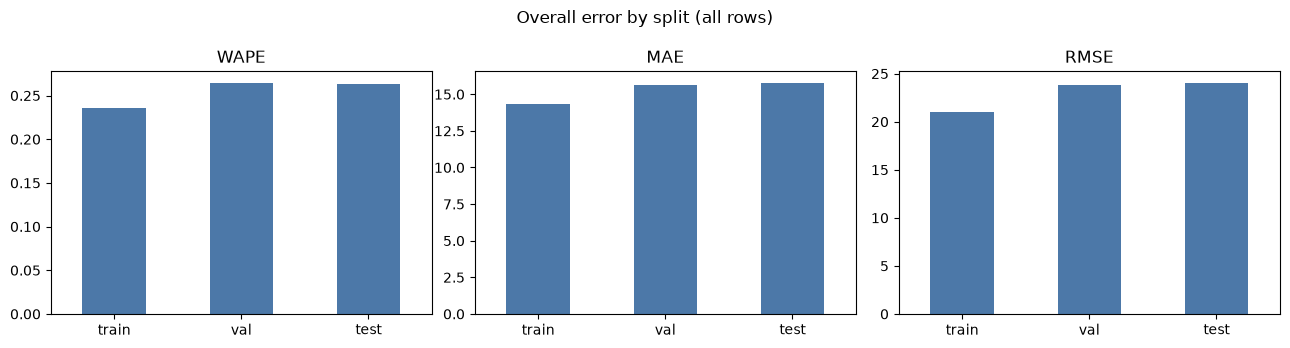

In [5]:
allrows = overall[overall["view"] == "all_rows"].set_index("split").reindex(["train", "val", "test"])
fig, axes = plt.subplots(1, 3, figsize=(13, 3.5))
for ax, col in zip(axes, ["WAPE", "MAE", "RMSE"]):
    allrows[col].plot(kind="bar", ax=ax, color="#4C78A8")
    ax.set_title(col); ax.set_xlabel(""); ax.tick_params(axis="x", rotation=0)
fig.suptitle("Overall error by split (all rows)")
plt.tight_layout(); plt.show()

## 3. Overfitting / generalization check

A small **train → val** gap means the model isn't memorizing; **val ≈ test** means the validation window is a fair stand-in for the future.

In [6]:
w = allrows["WAPE"]
print(f"WAPE  train={w.get('train', np.nan):.4f}  val={w['val']:.4f}  test={w['test']:.4f}")
if "train" in w.index:
    print(f"  train -> val gap : {w['val'] - w['train']:+.4f}")
print(f"  val   -> test gap: {w['test'] - w['val']:+.4f}")

WAPE  train=0.2359  val=0.2649  test=0.2638
  train -> val gap : +0.0289
  val   -> test gap: -0.0011


## 4. Stockout censoring effect

On stockout days actual sales are capped below true demand, so a correct forecast looks like an over-forecast. Watch the positive **all_rows** bias shrink toward ~0 for **in_stock**.

In [7]:
piv = overall.pivot_table(index="split", columns="view", values=["WAPE", "bias"]).reindex(["train", "val", "test"])
display(piv)
print("Positive all_rows bias that vanishes for in_stock == the censored-demand artifact, not a model error.")

WAPE              bias         
view  all_rows in_stock all_rows in_stock
split                                    
train   0.2359   0.2359  -0.0008  -0.0008
val     0.2649   0.2413   1.5365   0.0651
test    0.2638   0.2407   1.4120  -0.0557

Positive all_rows bias that vanishes for in_stock == the censored-demand artifact, not a model error.


## 5. Segment breakdowns (test)

Where does the error concentrate? By channel, category, promo, and stockout.

In [8]:
for name in ["channel", "category", "promo", "stockout"]:
    bd = art.get(f"breakdown_{name}")
    if bd is not None:
        print(f"\n=== TEST breakdown by {name} ===")
        display(bd)


=== TEST breakdown by channel ===


,channel,n,wape,mae,rmse,bias,actual_sum,pred_sum
0,Hypermarket,44160,0.2651,18.0435,27.1378,1.6808,"3,006,009.0000","3,080,233.7828"
1,E-commerce,22080,0.2647,15.8785,23.8208,1.4085,"1,324,395.0000","1,355,495.5467"
2,Supermarket,22080,0.2595,12.3992,18.6141,0.9573,"1,054,882.0000","1,076,018.3190"
3,Convenience,4048,0.2592,9.4018,14.2690,0.9779,"146,826.0000","150,784.4253"



=== TEST breakdown by category ===


,category,n,wape,mae,rmse,bias,actual_sum,pred_sum
0,Beverages,22356,0.2640,16.0287,24.4147,2.3489,"1,357,143.0000","1,409,655.5136"
1,Snacks,21988,0.2666,19.6751,29.5769,0.8709,"1,622,957.0000","1,642,106.7649"
2,Personal Care,16744,0.2590,14.1495,21.6796,1.2125,"914,839.0000","935,141.8213"
3,Dairy,16468,0.2625,13.6441,20.2511,1.2039,"855,900.0000","875,726.2601"
4,Home Care,14812,0.2645,13.9525,20.6910,1.2577,"781,273.0000","799,901.7139"



=== TEST breakdown by promo ===


,promo_flag,n,wape,mae,rmse,bias,actual_sum,pred_sum,segment
0,0,85229,0.2641,14.7512,22.0843,1.3758,"4,760,121.0000","4,877,377.5903",non_promo
1,1,7139,0.2617,28.2948,40.9273,1.8439,"771,991.0000","785,154.4836",promo



=== TEST breakdown by stockout ===


,stock_out_flag,n,wape,mae,rmse,bias,actual_sum,pred_sum,segment
0,0,89643,0.2407,14.7677,22.1254,-0.0557,"5,499,439.0000","5,494,448.5660",in_stock
1,1,2725,4.1444,49.6919,59.4851,49.6919,"32,673.0000","168,083.5078",stockout


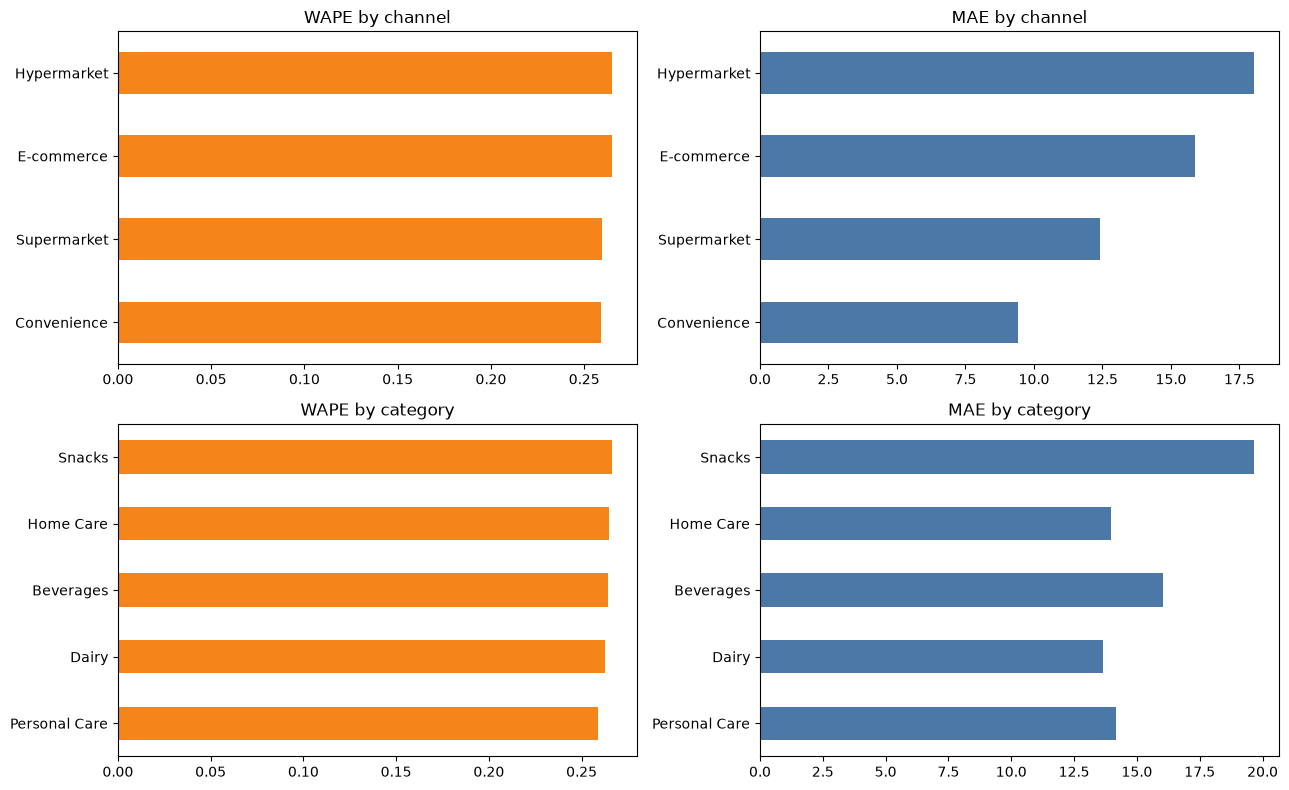

In [9]:
fig, axes = plt.subplots(2, 2, figsize=(13, 8))
for row, name in enumerate(["channel", "category"]):
    bd = art[f"breakdown_{name}"].sort_values("wape")
    bd.plot(x=name, y="wape", kind="barh", ax=axes[row, 0], legend=False, color="#F58518")
    axes[row, 0].set_title(f"WAPE by {name}"); axes[row, 0].set_ylabel("")
    bd.plot(x=name, y="mae", kind="barh", ax=axes[row, 1], legend=False, color="#4C78A8")
    axes[row, 1].set_title(f"MAE by {name}"); axes[row, 1].set_ylabel("")
plt.tight_layout(); plt.show()

## 6. Business proxy (test)

Turns forecast error into euros: over-forecast ties up capital at `purchase_cost`; under-forecast loses unit margin (`list_price * margin_pct`).

,value
overstock_units,"794,825.0837"
understock_units,"664,405.0098"
overstock_cost,"3,571,250.3459"
stockout_cost_lost_margin,"1,865,517.9301"
total_business_cost,"5,436,768.2760"


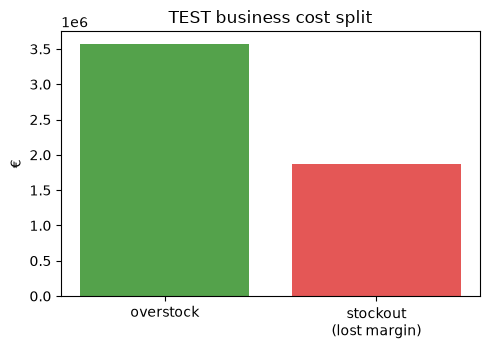

Total business cost: €5,436,768


In [10]:
bp = metrics["test"]["business_proxy"]
display(pd.Series(bp).to_frame("value"))
plt.figure(figsize=(5, 3.6))
plt.bar(["overstock", "stockout\n(lost margin)"],
        [bp["overstock_cost"], bp["stockout_cost_lost_margin"]],
        color=["#54A24B", "#E45756"])
plt.title("TEST business cost split"); plt.ylabel("€")
plt.tight_layout(); plt.show()
print(f"Total business cost: €{bp['total_business_cost']:,.0f}")

## 7. Feature importance

Which signals the model actually leans on. Demand lags/rollings and the (out-of-fold) series mean should dominate.

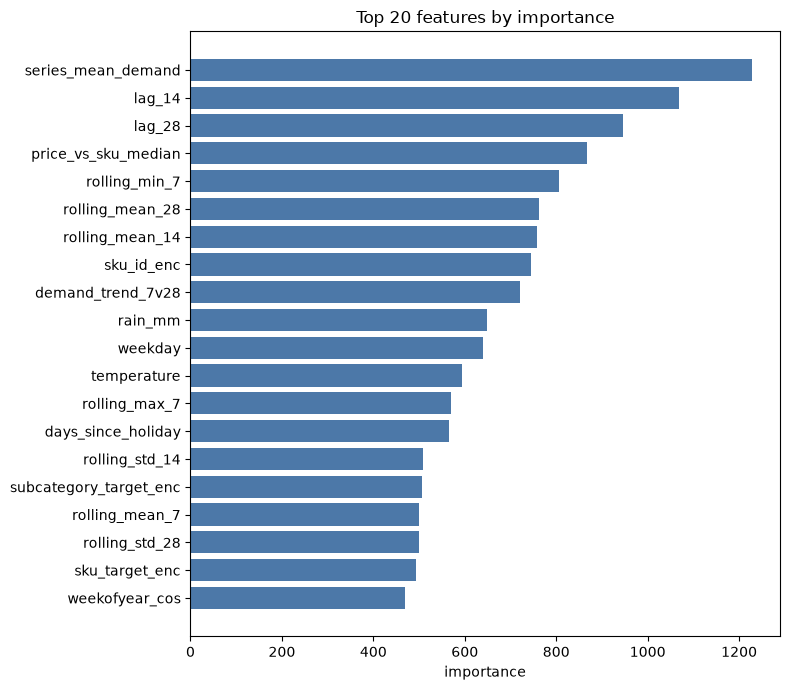

In [11]:
if art["feature_importance"] is None:
    print(f"No feature_importance.csv for '{MODEL}' — this is a sequence model "
          "(the GRU learns lags internally, so there is no tabular importance table).")
else:
    fi = art["feature_importance"].head(20).iloc[::-1]
    plt.figure(figsize=(8, 7))
    plt.barh(fi["feature"], fi["importance"], color="#4C78A8")
    plt.title("Top 20 features by importance"); plt.xlabel("importance")
    plt.tight_layout(); plt.show()

## 8. Failure-mode analysis (per-row test predictions)

Using `predictions_test.parquet` (`error = y_pred - units_sold`, plus `abs_error`). We look at the error distribution, calibration, and the Part B failure modes: sparse SKUs, promo spikes, stockout censoring, and drift.

In [12]:
p = pred_test.copy()
p["date"] = pd.to_datetime(p["date"])
p["signed_pct"] = np.where(p["units_sold"] > 0, p["error"] / p["units_sold"], np.nan)
print(f"rows={len(p):,}  mean bias={p['error'].mean():+.3f}  median abs error={p['abs_error'].median():.2f}")
p[["units_sold", "y_pred", "error", "abs_error"]].describe().T

rows=92,368  mean bias=+1.412  median abs error=9.68


,count,mean,std,min,25%,50%,75%,max
units_sold,"92,368.0000",59.8921,45.4727,0.0000,25.0000,49.0000,83.0000,485.0000
y_pred,"92,368.0000",61.3040,39.4136,5.5149,28.9866,55.3715,85.8957,338.0290
error,"92,368.0000",1.4120,24.0311,-230.1345,-8.7655,0.4379,10.5930,306.0290
abs_error,"92,368.0000",15.7980,18.1634,0.0006,3.9181,9.6761,21.0497,306.0290


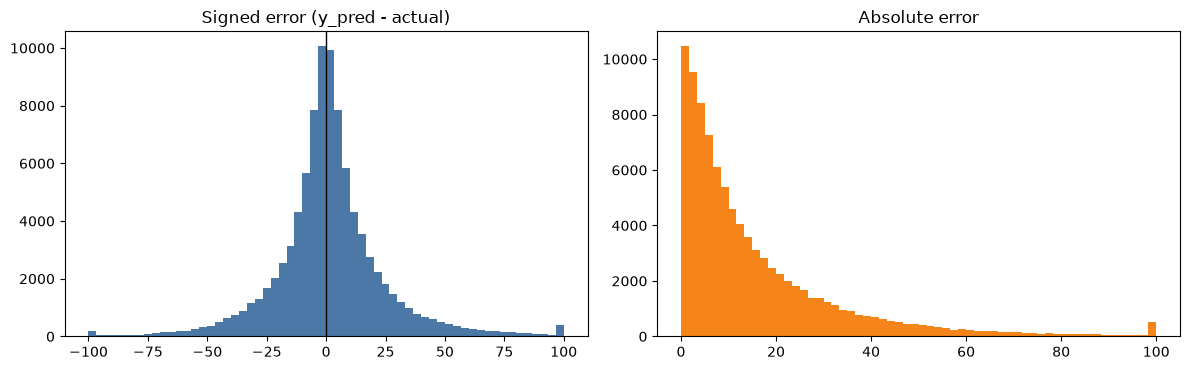

In [13]:
fig, axes = plt.subplots(1, 2, figsize=(12, 3.8))
axes[0].hist(p["error"].clip(-100, 100), bins=60, color="#4C78A8")
axes[0].axvline(0, color="k", lw=1); axes[0].set_title("Signed error (y_pred - actual)")
axes[1].hist(p["abs_error"].clip(0, 100), bins=60, color="#F58518")
axes[1].set_title("Absolute error")
plt.tight_layout(); plt.show()

### Calibration — predicted vs actual
Points on the dashed line = well calibrated. Consistent gaps reveal systematic over/under-forecasting.

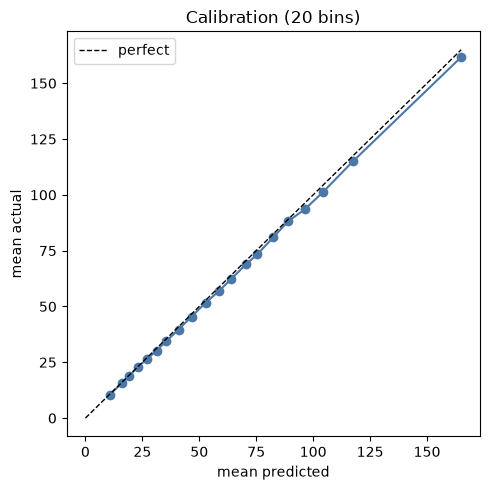

In [14]:
cal = (
    p.assign(bin=pd.qcut(p["y_pred"], q=20, duplicates="drop"))
    .groupby("bin", observed=True)
    .agg(pred=("y_pred", "mean"), actual=("units_sold", "mean"))
)
plt.figure(figsize=(5, 5))
plt.plot(cal["pred"], cal["actual"], "o-", color="#4C78A8")
lim = [0, float(max(cal["pred"].max(), cal["actual"].max()))]
plt.plot(lim, lim, "k--", lw=1, label="perfect")
plt.xlabel("mean predicted"); plt.ylabel("mean actual"); plt.title("Calibration (20 bins)")
plt.legend(); plt.tight_layout(); plt.show()

### Failure mode A — sparse / low-volume series
Low-demand `(store, sku)` series are noisier and usually have the worst WAPE (cold-start-like behaviour).

In [15]:
def series_wape(g):
    denom = g["units_sold"].sum()
    return np.nan if denom == 0 else g["abs_error"].sum() / denom

series = (
    p.groupby(["store_id", "sku_id"])
    .apply(lambda g: pd.Series({"n": len(g), "avg_demand": g["units_sold"].mean(), "wape": series_wape(g)}),
           include_groups=False)
    .reset_index()
)
print("Worst 10 series by WAPE:")
display(series.sort_values("wape", ascending=False).head(10))

Worst 10 series by WAPE:


,store_id,sku_id,n,avg_demand,wape
996,STORE0013,SKU0086,92.0000,5.4022,0.4186
647,STORE0009,SKU0010,92.0000,34.1304,0.3714
708,STORE0009,SKU0087,92.0000,24.9674,0.3698
386,STORE0005,SKU0084,92.0000,24.9891,0.3672
587,STORE0008,SKU0038,92.0000,99.3152,0.3595
817,STORE0011,SKU0023,92.0000,83.1196,0.3438
35,STORE0001,SKU0046,92.0000,109.4783,0.3368
826,STORE0011,SKU0033,92.0000,84.0870,0.3357
472,STORE0006,SKU0095,92.0000,32.0435,0.3347
398,STORE0005,SKU0101,92.0000,17.9457,0.3328


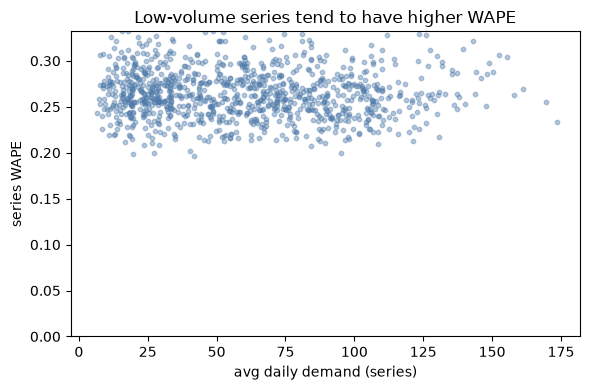

In [16]:
plt.figure(figsize=(6, 4))
plt.scatter(series["avg_demand"], series["wape"], s=10, alpha=0.4, color="#4C78A8")
plt.xlabel("avg daily demand (series)"); plt.ylabel("series WAPE")
plt.title("Low-volume series tend to have higher WAPE")
plt.ylim(0, min(2.0, float(series["wape"].quantile(0.99))))
plt.tight_layout(); plt.show()

### Failure mode B — promo spikes
Promotions cause demand spikes that are hard to hit. Large MAE plus net-negative bias on promo rows = the model under-predicts spikes.

In [17]:
promo_err = p.groupby("promo_flag").agg(
    n=("error", "size"), bias=("error", "mean"),
    mae=("abs_error", "mean"), share_under=("error", lambda s: (s < 0).mean()),
)
promo_err.index = promo_err.index.map({0: "non_promo", 1: "promo"})
display(promo_err)

,n,bias,mae,share_under
promo_flag,,,,
non_promo,85229,1.3758,14.7512,0.4842
promo,7139,1.8439,28.2948,0.4943


### Failure mode C — stockout censoring (row level)
Confirms the aggregate story: strong positive bias on stockout rows because actuals are capped.

In [18]:
so = p.groupby("stock_out_flag").agg(n=("error", "size"), bias=("error", "mean"), mae=("abs_error", "mean"))
so.index = so.index.map({0: "in_stock", 1: "stockout"})
display(so)

,n,bias,mae
stock_out_flag,,,
in_stock,89643,-0.0557,14.7677
stockout,2725,49.6919,49.6919


### Failure mode D — error drift across the test window
Rising MAE or a trending bias over the 14-day-ahead window signals the model degrades further out (or a regime change).

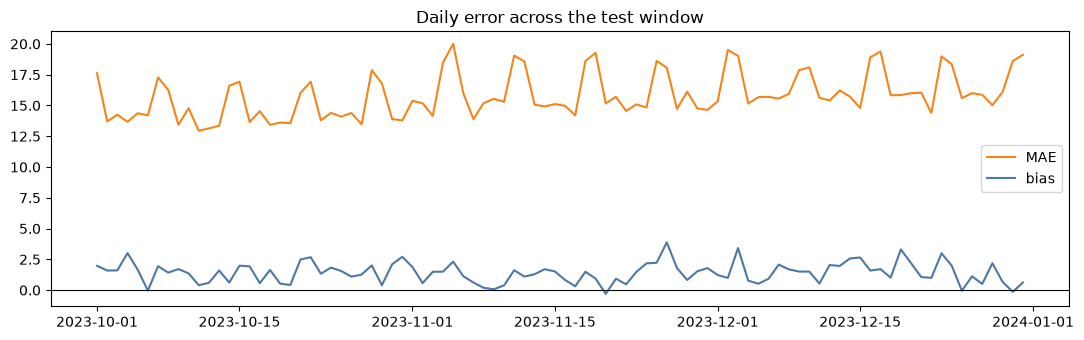

In [19]:
daily = p.groupby("date").agg(bias=("error", "mean"), mae=("abs_error", "mean"))
fig, ax = plt.subplots(figsize=(11, 3.5))
ax.plot(daily.index, daily["mae"], color="#F58518", label="MAE")
ax.plot(daily.index, daily["bias"], color="#4C78A8", label="bias")
ax.axhline(0, color="k", lw=0.8); ax.set_title("Daily error across the test window"); ax.legend()
plt.tight_layout(); plt.show()

In [20]:
cols = ["date", "store_id", "sku_id", "channel", "category", "promo_flag",
        "stock_out_flag", "units_sold", "y_pred", "error"]
print("20 largest absolute errors:")
display(p.nlargest(20, "abs_error")[cols])

20 largest absolute errors:


,date,store_id,sku_id,channel,category,promo_flag,stock_out_flag,units_sold,y_pred,error
39365,2023-12-21,STORE0006,SKU0034,Hypermarket,Snacks,1,0,32,338.0290,306.0290
75619,2023-12-27,STORE0011,SKU0027,Hypermarket,Snacks,1,1,19,268.0588,249.0588
1125,2023-10-22,STORE0001,SKU0017,Hypermarket,Beverages,1,1,6,252.6239,246.6239
23113,2023-10-22,STORE0004,SKU0017,Hypermarket,Beverages,1,1,24,267.7796,243.7796
83522,2023-12-18,STORE0012,SKU0034,E-commerce,Snacks,1,0,485,254.8655,-230.1345
53989,2023-12-17,STORE0008,SKU0035,Hypermarket,Snacks,0,1,47,262.2135,215.2135
2391,2023-12-31,STORE0001,SKU0035,Hypermarket,Snacks,0,0,441,228.9410,-212.0590
1875,2023-11-05,STORE0001,SKU0027,Hypermarket,Snacks,1,0,27,235.8060,208.8060
31987,2023-12-03,STORE0005,SKU0035,Hypermarket,Snacks,0,1,39,240.9335,201.9335
3269,2023-11-19,STORE0001,SKU0046,Hypermarket,Snacks,1,0,22,223.4410,201.4410


## 9. Takeaways

- **Headline**: read `test` WAPE on the **in_stock** view — it removes the stockout censoring penalty.
- **Overfit**: train→val→test WAPE gaps are small ⇒ the baseline generalizes.
- **Where it hurts**: promo spikes (high MAE, under-forecast) and sparse low-volume series (high WAPE).
- **Business lens**: overstock vs. lost-margin split shows which error direction is costlier to fix first.
- **Next**: compare this table against the deep-learning model (Part C) on the same splits/metrics.